### **1. Data Ingestion and Structural Overview
The dataset FlipkartReviews_Sentiment_Analysis_30000x25.csv contains 30,000 records across 25 features**

In [ ]:
import numpy as np
import pandas as pd

# Load the dataset
dataset_path = "Flipkart_Reviews_Sentiment_Analysis_30000x25.csv"
df = pd.read_csv(dataset_path)

# 1. Dataset Shape and Columns
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Columns in Dataset:")
print(list(df.columns))

# Display the first 10 records
print("\nFirst 10 records:")
df.head(10)

Dataset Shape: 30000 rows, 25 columns

Columns in Dataset:
['Review_ID', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Product_Price', 'Discount_Percentage', 'Selling_Price', 'Rating', 'Review_Summary', 'Review_Text', 'Sentiment', 'Sentiment_Score', 'Customer_City', 'Review_Date', 'Verified_Purchase', 'Helpful_Votes', 'Not_Helpful_Votes', 'Payment_Method', 'Purchase_Channel', 'Delivery_Partner', 'Delivery_Days', 'Customer_Device', 'Review_Confidence', 'Customer_Experience_Score']

First 10 records:


,Review_ID,Product_ID,Product_Name,Category,Brand,Product_Price,Discount_Percentage,Selling_Price,Rating,Review_Summary,...,Verified_Purchase,Helpful_Votes,Not_Helpful_Votes,Payment_Method,Purchase_Channel,Delivery_Partner,Delivery_Days,Customer_Device,Review_Confidence,Customer_Experience_Score
0,FKR000001,PROD3286,HP 15s,Laptops,Wakefit,77090.0,15.7,64987.0,5,Loved it,...,Yes,3,2,Cash on Delivery,Website,Ekart,4,Android,0.712,1
1,FKR000002,PROD4257,LG 55 Smart TV,Televisions,Wakefit,47705.0,7.9,43936.0,5,Worth it,...,No,3,2,Credit Card,Website,Xpressbees,5,Windows,0.708,1
2,FKR000003,PROD6514,Sony WH-CH520,Audio,Realme,9835.0,12.0,8655.0,5,Great product,...,No,2,0,UPI,Website,Blue Dart,3,Windows,0.738,1
3,FKR000004,PROD5803,Deep Learning Book,Books,Prestige,1052.0,20.2,839.0,3,Average,...,No,1,0,Cash on Delivery,Mobile App,Ekart,6,Android,0.782,2
4,FKR000005,PROD5554,LG Washing Machine,Appliances,Sony,16314.0,6.7,15221.0,5,Very good,...,No,3,0,Credit Card,Website,Blue Dart,4,iOS,0.890,3
5,FKR000006,PROD8573,Acer Aspire 5,Laptops,ASUS,57394.0,2.9,55730.0,3,Could be better,...,Yes,3,2,Debit Card,Mobile App,Delhivery,6,Android,0.909,3
6,FKR000007,PROD9179,Wakefit Pillow,Home & Kitchen,ASUS,7984.0,14.0,6866.0,5,Excellent,...,No,0,1,Credit Card,Website,Delhivery,4,iOS,0.959,5
7,FKR000008,PROD4593,Bajaj Iron,Appliances,Redmi,13509.0,15.9,11361.0,5,Superb,...,No,7,3,UPI,Mobile App,Ekart,3,iOS,0.795,2
8,FKR000009,PROD9669,Milton Lunch Box,Home & Kitchen,HP,7808.0,3.8,7511.0,3,Average,...,Yes,4,3,UPI,Mobile Web,Xpressbees,3,Windows,0.752,3
9,FKR000010,PROD5315,ASUS Vivobook 15,Laptops,LG,69220.0,16.1,58076.0,4,Superb,...,Yes,5,2,Debit Card,Mobile Web,Xpressbees,5,iOS,0.832,2


### **2. Data Type Identification and Column Categorization
The 25 attributes span identifiers, numerical metrics, customer metadata, and unstructured text fields**

In [ ]:
# Check schema data types
print("Data Types Overview:")
print(df.dtypes)

# Categorize columns according to analytical intent
date_cols = ["Review_Date"]  #

text_nlp_cols = ["Review_Summary", "Review_Text"]  #

target_col = ["Sentiment"]  #

numerical_cols = [
    "Product_Price",
    "Discount_Percentage",
    "Selling_Price",
    "Rating",
    "Sentiment_Score",
    "Helpful_Votes",
    "Not_Helpful_Votes",
    "Delivery_Days",
    "Review_Confidence",
    "Customer_Experience_Score",
]  #

categorical_cols = [
    "Review_ID",
    "Product_ID",
    "Product_Name",
    "Category",
    "Brand",
    "Customer_City",
    "Verified_Purchase",
    "Payment_Method",
    "Purchase_Channel",
    "Delivery_Partner",
    "Customer_Device",
]  #

print(f"\nTotal Categorical: {len(categorical_cols)}")
print(f"Total Numerical:   {len(numerical_cols)}")
print(f"Total Text/NLP:    {len(text_nlp_cols)}")
print(f"Total Date:        {len(date_cols)}")
print(f"Target:            {len(target_col)}")

Data Types Overview:
Review_ID                     object
Product_ID                    object
Product_Name                  object
Category                      object
Brand                         object
Product_Price                float64
Discount_Percentage          float64
Selling_Price                float64
Rating                         int64
Review_Summary                object
Review_Text                   object
Sentiment                     object
Sentiment_Score              float64
Customer_City                 object
Review_Date                   object
Verified_Purchase             object
Helpful_Votes                  int64
Not_Helpful_Votes              int64
Payment_Method                object
Purchase_Channel              object
Delivery_Partner              object
Delivery_Days                  int64
Customer_Device               object
Review_Confidence            float64
Customer_Experience_Score      int64
dtype: object

Total Categorical: 11
Total Numerical: 

### **3. Missing Value Audit**

In [ ]:
# Calculate null counts and proportions
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame(
    {
        "Missing_Count": null_counts,
        "Missing_Percentage": null_percentages.round(2),
    }
).sort_values(by="Missing_Percentage", ascending=False)

print("Columns with Missing Values:")
print(missing_summary[missing_summary["Missing_Count"] > 0])

Columns with Missing Values:
                Missing_Count  Missing_Percentage
Customer_City             300                 1.0
Review_Summary            240                 0.8
Payment_Method            150                 0.5


### **4. Duplicate Detection and Resolution Strategy
Duplicates can emerge from repeated API logging or copied reviews across accounts.**

In [ ]:
# 1. Exact primary key duplicates
duplicate_ids = df.duplicated(subset=["Review_ID"]).sum()

# 2. Text-level duplicates
duplicate_texts = df.duplicated(subset=["Review_Text"]).sum()

# 3. Composite duplicates (same product, same customer text, same rating)
composite_duplicates = df.duplicated(
    subset=["Product_ID", "Review_Text", "Rating"]
).sum()

print(f"Duplicate Review_IDs:                  {duplicate_ids}")
print(f"Identical Review_Texts:                {duplicate_texts}")
print(f"Composite Duplicates (Product + Text): {composite_duplicates}")

Duplicate Review_IDs:                  0
Identical Review_Texts:                29040
Composite Duplicates (Product + Text): 54


### **5. Datetime Parsing and Temporal Feature Extraction
Transform Review_Date into standard datetime objects and extract temporal dimensions.**

In [ ]:
# Convert to datetime format
df["Review_Date"] = pd.to_datetime(df["Review_Date"], errors="coerce")

# Extract temporal components
df["Review_Year"] = df["Review_Date"].dt.year
df["Review_Month"] = df["Review_Date"].dt.month
df["Review_Day"] = df["Review_Date"].dt.day
df["Review_DayOfWeek"] = df["Review_Date"].dt.day_name()

print("Temporal feature extraction completed:")
df[["Review_Date", "Review_Year", "Review_Month", "Review_Day", "Review_DayOfWeek"]].head()

Temporal feature extraction completed:


,Review_Date,Review_Year,Review_Month,Review_Day,Review_DayOfWeek
0,2025-08-17,2025,8,17,Sunday
1,2026-07-29,2026,7,29,Wednesday
2,2025-08-09,2025,8,9,Saturday
3,2026-07-20,2026,7,20,Monday
4,2026-01-25,2026,1,25,Sunday


### **6. Descriptive Statistical Analysis**
Statistical inspection identifies dispersion, spread, and outlier boundaries for the core operational metrics. **

In [ ]:
key_numeric_columns = [
    "Product_Price",
    "Selling_Price",
    "Rating",
    "Discount_Percentage",
    "Delivery_Days",
    "Helpful_Votes",
]  #

stats_summary = df[key_numeric_columns].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]
stats_summary["IQR"] = stats_summary["75%"] - stats_summary["25%"]

print("Statistical Summary of Key Numerical Features:")
print(stats_summary.round(2))

Statistical Summary of Key Numerical Features:
                       count      mean       std    min      25%      50%  \
Product_Price        30000.0  27499.71  30744.12  150.0  3621.75  11510.0   
Selling_Price        30000.0  22514.37  25478.06   95.0  2945.75   9456.0   
Rating               30000.0      3.80      1.30    1.0     3.00      4.0   
Discount_Percentage  30000.0     18.07      9.62    0.0    11.20     17.9   
Delivery_Days        30000.0      4.07      1.92    1.0     3.00      4.0   
Helpful_Votes        30000.0      3.19      1.82    0.0     2.00      3.0   

                          75%       max       IQR  
Product_Price        46121.00  119988.0  42499.25  
Selling_Price        37233.75  119941.0  34288.00  
Rating                   5.00       5.0      2.00  
Discount_Percentage     24.60      54.0     13.40  
Delivery_Days            5.00      12.0      2.00  
Helpful_Votes            4.00      14.0      2.00  


### **7. Sanity Checks and Anomaly Detection** **bold text**
Evaluate domain-specific boundaries to isolate unrealistic entries[cite: 1]:
1. Rating: Must reside strictly within $[1.0, 5.0]$[cite: 1].
2. Discount Percentage: Must fall within $[0.0, 100.0]$[cite: 1].
3. Price Consistency: Product_Price and Selling_Price must be $> 0$, and Selling_Price should not exceed Product_Price[cite: 1].
4. Delivery Days: Negative fulfillment cycles ($\text{Delivery\_Days} < 0$) are invalid[cite: 1].
5. Customer Experience Score: Ensure values fall within the established system bounds (e.g., $1.0$ to $5.0$ or $0.0$ to $10.0$)[cite: 1].

In [ ]:
# Identify boundary violations
invalid_ratings = df[(df["Rating"] < 1.0) | (df["Rating"] > 5.0)]
invalid_discounts = df[(df["Discount_Percentage"] < 0) | (df["Discount_Percentage"] > 100)]
invalid_prices = df[(df["Product_Price"] <= 0) | (df["Selling_Price"] <= 0)]
price_mismatch = df[df["Selling_Price"] > df["Product_Price"]]
invalid_delivery = df[df["Delivery_Days"] < 0]
invalid_exp_score = df[(df["Customer_Experience_Score"] < 0) | (df["Customer_Experience_Score"] > 10)]

print(f"Invalid Ratings (<1 or >5):               {len(invalid_ratings)}")
print(f"Invalid Discounts (<0% or >100%):         {len(invalid_discounts)}")
print(f"Non-positive Prices (<=0):                {len(invalid_prices)}")
print(f"Selling Price > Product Price:            {len(price_mismatch)}")
print(f"Negative Delivery Days (<0):              {len(invalid_delivery)}")
print(f"Out-of-range Customer Experience Scores:  {len(invalid_exp_score)}")

Invalid Ratings (<1 or >5):               0
Invalid Discounts (<0% or >100%):         0
Non-positive Prices (<=0):                0
Selling Price > Product Price:            0
Negative Delivery Days (<0):              0
Out-of-range Customer Experience Scores:  0


### **8. Cleaning Pipeline and Processed Dataset Export**

Consolidate all cleansing criteria into a reproducible data processing function:

In [ ]:
def clean_flipkart_dataset(raw_df: pd.DataFrame) -> pd.DataFrame:
    cleaned = raw_df.copy()

    # 1. Deduplication
    cleaned = cleaned.drop_duplicates(subset=["Review_ID"], keep="first")
    cleaned = cleaned.drop_duplicates(
        subset=["Product_ID", "Review_Text", "Rating"], keep="first"
    )

    # 2. Text Integrity (Ensure non-null strings for NLP inputs)
    cleaned["Review_Summary"] = cleaned["Review_Summary"].fillna("No Summary").astype(str)
    cleaned = cleaned.dropna(subset=["Review_Text", "Sentiment"])
    cleaned = cleaned[cleaned["Review_Text"].str.strip().str.len() > 0]

    # 3. Domain Value Filtering
    valid_mask = (
        (cleaned["Rating"] >= 1.0) & (cleaned["Rating"] <= 5.0) &
        (cleaned["Discount_Percentage"] >= 0.0) & (cleaned["Discount_Percentage"] <= 100.0) &
        (cleaned["Product_Price"] > 0) & (cleaned["Selling_Price"] > 0) &
        (cleaned["Selling_Price"] <= cleaned["Product_Price"]) &
        (cleaned["Delivery_Days"] >= 0)
    )
    cleaned = cleaned[valid_mask]

    # 4. Impute minor missing metadata (if applicable)
    if "Delivery_Partner" in cleaned.columns:
        cleaned["Delivery_Partner"] = cleaned["Delivery_Partner"].fillna("Unknown")
    if "Helpful_Votes" in cleaned.columns:
        cleaned["Helpful_Votes"] = cleaned["Helpful_Votes"].fillna(0)
    if "Not_Helpful_Votes" in cleaned.columns:
        cleaned["Not_Helpful_Votes"] = cleaned["Not_Helpful_Votes"].fillna(0)

    # 5. Datetime normalization
    cleaned["Review_Date"] = pd.to_datetime(cleaned["Review_Date"], errors="coerce")
    cleaned = cleaned.dropna(subset=["Review_Date"])

    cleaned["Review_Year"] = cleaned["Review_Date"].dt.year.astype(int)
    cleaned["Review_Month"] = cleaned["Review_Date"].dt.month.astype(int)
    cleaned["Review_Day"] = cleaned["Review_Date"].dt.day.astype(int)
    cleaned["Review_DayOfWeek"] = cleaned["Review_Date"].dt.day_name()

    cleaned.reset_index(drop=True, inplace=True)
    return cleaned

# Execute the pipeline
df_cleaned = clean_flipkart_dataset(df)

# Export cleaned artifact for Phase 2 EDA
output_filename = "Flipkart_Reviews_Cleaned.csv"
df_cleaned.to_csv(output_filename, index=False)

print(f"Data Cleaning Completed.")
print(f"Original Rows: {len(df)} | Cleaned Rows: {len(df_cleaned)}")
print(f"Saved artifact to: {output_filename}")

Data Cleaning Completed.
Original Rows: 30000 | Cleaned Rows: 29946
Saved artifact to: Flipkart_Reviews_Cleaned.csv


### **9. Analyze the distribution of Positive, Neutral, and Negative reviews.**

--- Sentiment Class Distribution ---
           Count  Percentage (%)
Sentiment                       
Positive   18629           62.21
Neutral     6014           20.08
Negative    5303           17.71


/tmp/ipykernel_2503/2602513122.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sentiment", order=["Positive", "Neutral", "Negative"], palette="Blues_d")


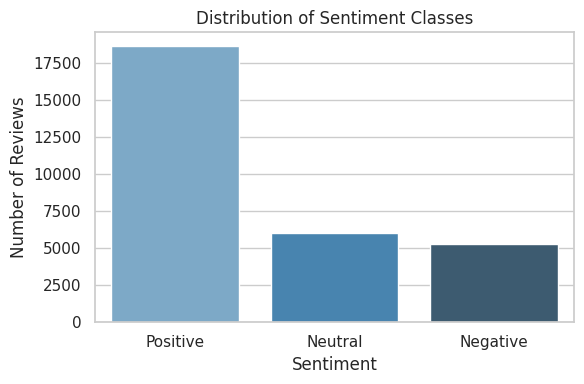

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load cleaned dataset produced in Phase 1
df = pd.read_csv("Flipkart_Reviews_Cleaned.csv")
sns.set_theme(style="whitegrid")

# 9. Sentiment Class Distribution
sentiment_counts = df["Sentiment"].value_counts()
sentiment_pct = df["Sentiment"].value_counts(normalize=True) * 100
print("--- Sentiment Class Distribution ---")
print(pd.DataFrame({"Count": sentiment_counts, "Percentage (%)": sentiment_pct.round(2)}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sentiment", order=["Positive", "Neutral", "Negative"], palette="Blues_d")
plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

### **10. Visualize the relationship between Rating and Sentiment using an appropriate chart.**

/tmp/ipykernel_2503/1049596481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sentiment", y="Rating", order=["Positive", "Neutral", "Negative"], palette="Set2")


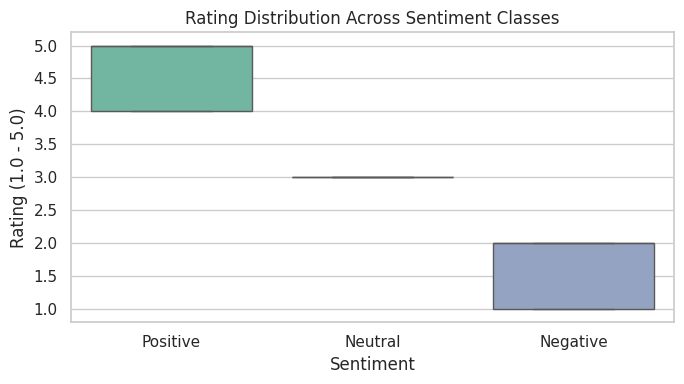


--- Sentiment Percentage per Rating Level ---
Sentiment  Negative  Neutral  Positive
Rating                                
1             100.0      0.0       0.0
2             100.0      0.0       0.0
3               0.0    100.0       0.0
4               0.0      0.0     100.0
5               0.0      0.0     100.0


In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="Sentiment", y="Rating", order=["Positive", "Neutral", "Negative"], palette="Set2")
plt.title("Rating Distribution Across Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Rating (1.0 - 5.0)")
plt.tight_layout()
plt.show()

# Cross-tabulation normalized across sentiment
rating_sentiment_crosstab = pd.crosstab(df["Rating"], df["Sentiment"], normalize="index") * 100
print("\n--- Sentiment Percentage per Rating Level ---")
print(rating_sentiment_crosstab.round(2))

### **11. Determine which product categories have the highest number of reviews.**


--- Review Volume by Category ---
Category
Appliances        3811
Mobiles           3802
Audio             3784
Laptops           3768
Home & Kitchen    3766
Fashion           3748
Books             3681
Televisions       3586
Name: count, dtype: int64


/tmp/ipykernel_2503/9784534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.head(8).values, y=top_categories.head(8).index, palette="viridis")


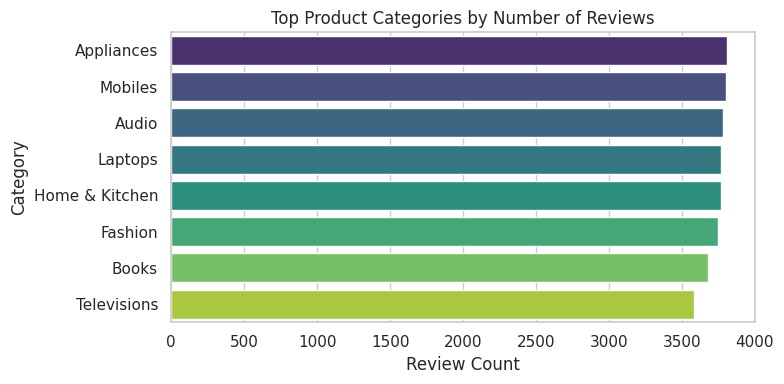

In [ ]:
#Top Categories by Review Volume
top_categories = df["Category"].value_counts()
print("\n--- Review Volume by Category ---")
print(top_categories.head(10))

plt.figure(figsize=(8, 4))
sns.barplot(x=top_categories.head(8).values, y=top_categories.head(8).index, palette="viridis")
plt.title("Top Product Categories by Number of Reviews")
plt.xlabel("Review Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### **12. Find the top 10 brands based on the number of reviews.**

/tmp/ipykernel_2503/454611520.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_brands.values, y=top_10_brands.index, palette="mako")



--- Top 10 Brands by Review Volume ---
Brand
ASUS        2373
HP          2363
Puma        2347
LG          2331
OnePlus     2330
Prestige    2322
Realme      2307
Samsung     2298
Wakefit     2292
Sony        2265
Name: count, dtype: int64


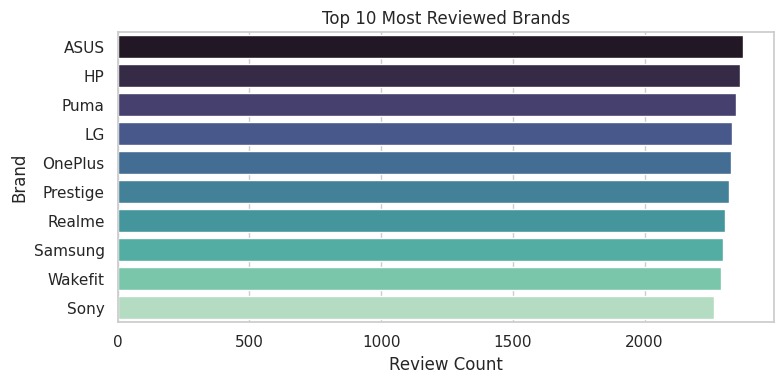

In [ ]:
top_10_brands = df["Brand"].value_counts().head(10)
print("\n--- Top 10 Brands by Review Volume ---")
print(top_10_brands)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_10_brands.values, y=top_10_brands.index, palette="mako")
plt.title("Top 10 Most Reviewed Brands")
plt.xlabel("Review Count")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

 1. Target Balance: Checking the class ratio for Positive, Neutral, and Negative reviews identifies potential imbalance that may require class weighting or stratified sampling in Phase 4.
2. Alignment Validation: Comparing Rating against Sentiment validates data consistency: negative sentiment should concentrate at 1–2 stars, while positive sentiment clusters at 4–5 stars.  
3. Volume Concentration: Isolating high-traffic Category and Brand segments identifies which product types dominate the dataset.

### **13. Analyze the average rating for each product category.**

In [ ]:
# Average Rating per Product Category
category_ratings = df.groupby("Category")["Rating"].agg(["count", "mean", "std"]).sort_values(by="mean", ascending=False)
print("--- Category Average Ratings ---")
print(category_ratings.round(2))

--- Category Average Ratings ---
                count  mean   std
Category                         
Audio            3784  3.83  1.29
Home & Kitchen   3766  3.81  1.30
Televisions      3586  3.81  1.29
Laptops          3768  3.81  1.30
Fashion          3748  3.81  1.31
Books            3681  3.80  1.32
Mobiles          3802  3.78  1.31
Appliances       3811  3.78  1.30


## **14. Compare the average selling price across different product categories.**


--- Category Selling Price Benchmarks ---
                    mean   median
Category                         
Televisions     57629.40  57466.0
Laptops         55772.38  54108.0
Mobiles         29503.88  28978.5
Appliances      22959.76  22650.0
Home & Kitchen   6252.88   6141.5
Audio            5258.94   5244.5
Fashion          3037.36   3018.5
Books             799.38    783.0


/tmp/ipykernel_2503/1774371986.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_prices.index, y=category_prices["mean"], palette="crest")


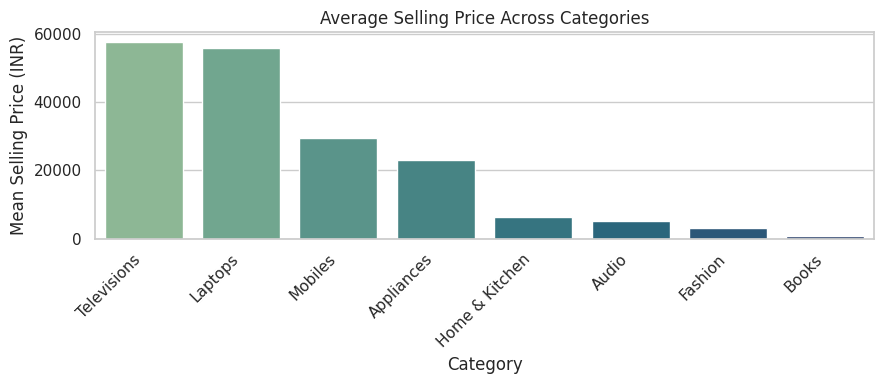

In [ ]:
# Average Selling Price across Product Categories
category_prices = df.groupby("Category")["Selling_Price"].agg(["mean", "median"]).sort_values(by="mean", ascending=False)
print("\n--- Category Selling Price Benchmarks ---")
print(category_prices.round(2))

plt.figure(figsize=(9, 4))
sns.barplot(x=category_prices.index, y=category_prices["mean"], palette="crest")
plt.title("Average Selling Price Across Categories")
plt.xlabel("Category")
plt.ylabel("Mean Selling Price (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### **15. Analyze whether higher discounts are associated with better or worse customer sentiment**

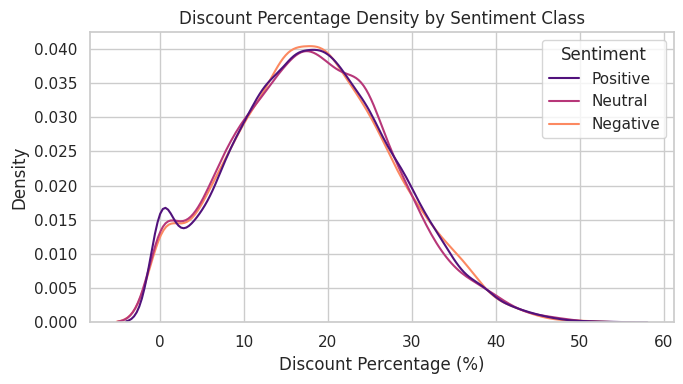


--- Discount Distribution per Sentiment Class ---
             count   mean   std  min   25%   50%    75%   max
Sentiment                                                    
Negative    5303.0  18.12  9.58  0.0  11.3  17.9  24.60  51.3
Neutral     6014.0  17.96  9.57  0.0  11.0  17.8  24.48  49.4
Positive   18629.0  18.09  9.65  0.0  11.3  18.0  24.70  54.0


In [ ]:
# Discount Percentage vs. Sentiment Association
plt.figure(figsize=(7, 4))
sns.kdeplot(data=df, x="Discount_Percentage", hue="Sentiment", common_norm=False, palette="magma")
plt.title("Discount Percentage Density by Sentiment Class")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

discount_sentiment_stats = df.groupby("Sentiment")["Discount_Percentage"].describe()
print("\n--- Discount Distribution per Sentiment Class ---")
print(discount_sentiment_stats.round(2))

### **16. Study the relationship between Delivery_Days and Customer_Experience_Score.**

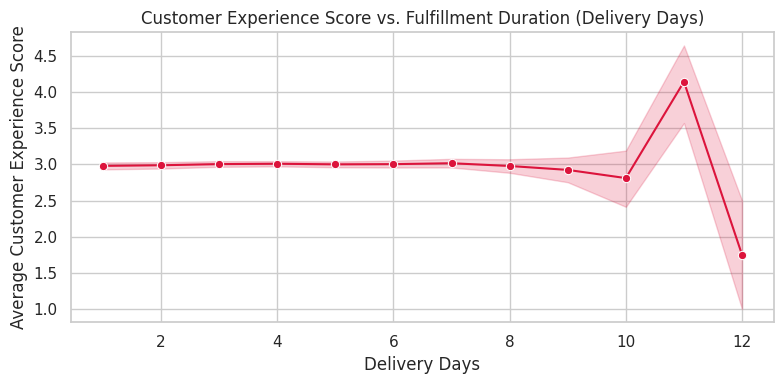


Correlation between Delivery_Days and Customer_Experience_Score: 0.003


In [ ]:
# Delivery Days vs. Customer Experience Score
plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x="Delivery_Days", y="Customer_Experience_Score", marker="o", color="crimson")
plt.title("Customer Experience Score vs. Fulfillment Duration (Delivery Days)")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Experience Score")
plt.tight_layout()
plt.show()

corr = df["Delivery_Days"].corr(df["Customer_Experience_Score"])
print(f"\nCorrelation between Delivery_Days and Customer_Experience_Score: {corr:.3f}")

**
1. Pricing Heterogeneity: Computing Selling_Price and Rating across categories accounts for differing baseline expectations across luxury and commodity goods.   
2. Discount Sensitivity: Kernel density estimation of Discount_Percentage per class evaluates whether deep discounts correlate with higher satisfaction or customer friction.   
3. Fulfillment Impact: Plotting Delivery_Days against Customer_Experience_Score measures logistics degradation and its relationship with negative feedback.**

### **17. Determine whether verified purchases have a different sentiment distribution from non-verified purchases.**

--- Sentiment Proportion by Purchase Verification (%) ---
Sentiment          Negative  Neutral  Positive
Verified_Purchase                             
No                    17.69    19.90     62.41
Yes                   17.73    20.27     62.01


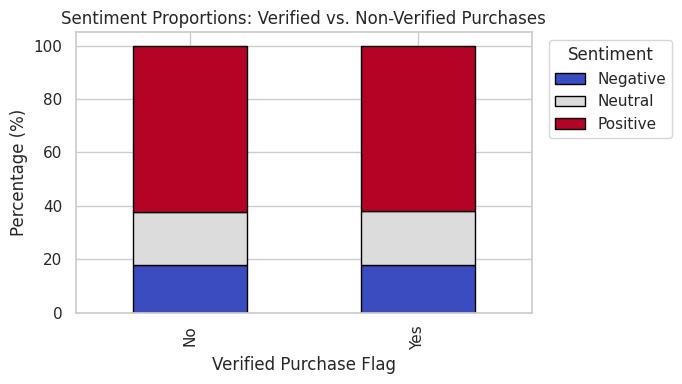

In [ ]:
#Sentiment Distribution: Verified vs. Non-Verified Purchases
vp_crosstab = pd.crosstab(df["Verified_Purchase"], df["Sentiment"], normalize="index") * 100
print("--- Sentiment Proportion by Purchase Verification (%) ---")
print(vp_crosstab.round(2))

vp_crosstab.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="coolwarm", edgecolor="black")
plt.title("Sentiment Proportions: Verified vs. Non-Verified Purchases")
plt.xlabel("Verified Purchase Flag")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### **18. Identify the most helpful reviews based on Helpful_Votes and analyze their sentiment.**


--- Sentiment Breakdown of Top 20 Most Helpful Reviews ---
Sentiment
Negative    12
Positive     5
Neutral      3
Name: count, dtype: int64


/tmp/ipykernel_2503/2184165630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=top_helpful_reviews, x="Sentiment", order=["Positive", "Neutral", "Negative"], palette="Set1")


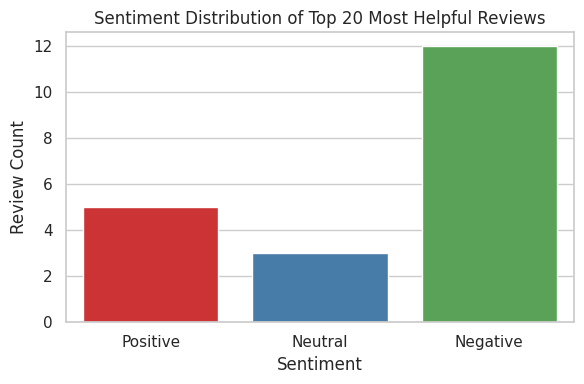


Top 3 Most Helpful Reviews Summary:
       Review_ID  Rating Sentiment  Helpful_Votes  Review_Summary
14881  FKR014891       2  Negative             14  Waste of money
28930  FKR028981       5  Positive             12        Worth it
23732  FKR023761       2  Negative             12    Disappointed


In [ ]:
# 18. High-Impact Reviews Analysis by Helpful_Votes
top_helpful_reviews = df.sort_values(by="Helpful_Votes", ascending=False).head(20)
print("\n--- Sentiment Breakdown of Top 20 Most Helpful Reviews ---")
print(top_helpful_reviews["Sentiment"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=top_helpful_reviews, x="Sentiment", order=["Positive", "Neutral", "Negative"], palette="Set1")
plt.title("Sentiment Distribution of Top 20 Most Helpful Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()

# Display sample high-influence reviews
print("\nTop 3 Most Helpful Reviews Summary:")
print(top_helpful_reviews[["Review_ID", "Rating", "Sentiment", "Helpful_Votes", "Review_Summary"]].head(3))

### **19. Generate a word frequency analysis for Positive, Neutral, and Negative reviews separately.**

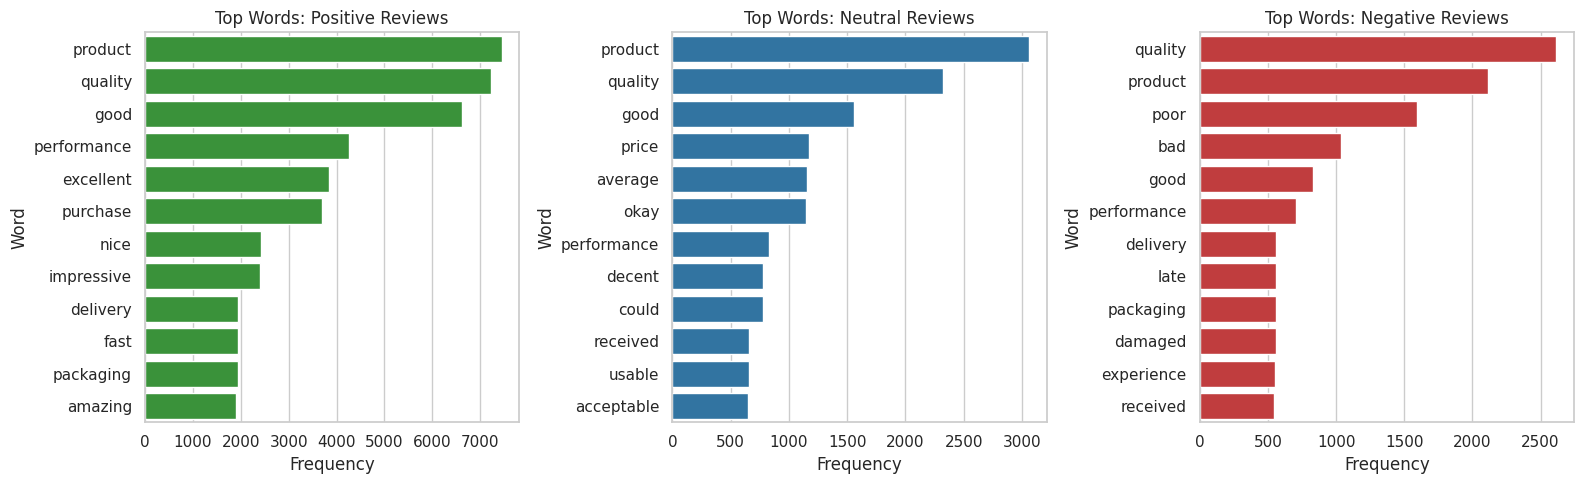

In [ ]:
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def extract_top_words(text_series: pd.Series, top_n: int = 15) -> pd.DataFrame:
    words = []
    for text in text_series.dropna():
        cleaned_text = re.sub(r"[^a-zA-Z\s]", "", str(text).lower())
        tokens = [w for w in cleaned_text.split() if w not in stop_words and len(w) > 2]
        words.extend(tokens)
    return pd.DataFrame(Counter(words).most_common(top_n), columns=["Word", "Frequency"])
pos_words = extract_top_words(df[df["Sentiment"] == "Positive"]["Review_Text"], top_n=12)
neu_words = extract_top_words(df[df["Sentiment"] == "Neutral"]["Review_Text"], top_n=12)
neg_words = extract_top_words(df[df["Sentiment"] == "Negative"]["Review_Text"], top_n=12)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

sns.barplot(x="Frequency", y="Word", data=pos_words, ax=axes[0], color="#2ca02c")
axes[0].set_title("Top Words: Positive Reviews")

sns.barplot(x="Frequency", y="Word", data=neu_words, ax=axes[1], color="#1f77b4")
axes[1].set_title("Top Words: Neutral Reviews")

sns.barplot(x="Frequency", y="Word", data=neg_words, ax=axes[2], color="#d62728")
axes[2].set_title("Top Words: Negative Reviews")

plt.tight_layout()
plt.show()

### **20, 21 & 26. Feature Synthesis, Normalization, and Character Cleaning Consolidating Review_Summary and Review_Text combines high-level sentiment summaries with detailed contextual feedback into Combined_Review. The cleaning step strips digits, punctuation, and non-ASCII artifacts while preserving sentiment-bearing tokens**

In [ ]:
import re
import pandas as pd
import numpy as np
import nltk

# Load cleaned artifact from Phase 1
df = pd.read_csv("Flipkart_Reviews_Cleaned.csv")

# 20. Combine Review_Summary and Review_Text
df["Review_Summary"] = df["Review_Summary"].fillna("").astype(str)
df["Review_Text"] = df["Review_Text"].fillna("").astype(str)
df["Combined_Review"] = (df["Review_Summary"] + " " + df["Review_Text"]).str.strip()

# 21 & 26. Cleaning pipeline: lowercasing, removal of punctuation, symbols, numbers, and extra spaces
def clean_raw_text(text: str) -> str:
    # Lowercase conversion
    text = text.lower()
    # Remove HTML tags and web URLs
    text = re.sub(r"<.*?>|https?://\S+|www\.\S+", "", text)
    # Remove numbers and numerical digits
    text = re.sub(r"\d+", "", text)
    # Remove punctuation, symbols, and special characters
    text = re.sub(r"[^\w\s]", "", text)
    # Normalize multiple whitespace characters to a single space
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Cleaned_Text"] = df["Combined_Review"].apply(clean_raw_text)

print("Original Combined Text Sample:")
print(df["Combined_Review"].iloc[0])
print("\nCleaned Text Sample:")
print(df["Cleaned_Text"].iloc[0])

Original Combined Text Sample:
Loved it good product, works perfectly, keyboard feels comfortable.

Cleaned Text Sample:
loved it good product works perfectly keyboard feels comfortable


### **22 & 23. Tokenization, Stop-Word Elimination, and Impact Metrics Tokenizing decomposes strings into discrete linguistic units. Removing standard English stop words filters low-signal function words while tracking sequence compression.**

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

# Preserve sentiment-critical negations from default stopword set
custom_stopwords = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "neither", "never"}
custom_stopwords = custom_stopwords - negation_words

# 22. Word Tokenization
df["Tokens_Raw"] = df["Cleaned_Text"].apply(word_tokenize)

# 23. Stop-Word Removal
df["Tokens_NoStop"] = df["Tokens_Raw"].apply(
    lambda tokens: [token for token in tokens if token not in custom_stopwords and len(token) > 1]
)

# Statistical comparison: Before vs After Stop-Word Removal
df["Word_Count_Before"] = df["Tokens_Raw"].apply(len)
df["Word_Count_After"] = df["Tokens_NoStop"].apply(len)

comparison_stats = pd.DataFrame({
    "Metric": ["Mean Word Count", "Median Word Count", "Max Word Count", "Total Vocabulary Count"],
    "Before Stop-Word Removal": [
        df["Word_Count_Before"].mean(),
        df["Word_Count_Before"].median(),
        df["Word_Count_Before"].max(),
        len(set([t for tokens in df["Tokens_Raw"] for t in tokens]))
    ],
    "After Stop-Word Removal": [
        df["Word_Count_After"].mean(),
        df["Word_Count_After"].median(),
        df["Word_Count_After"].max(),
        len(set([t for tokens in df["Tokens_NoStop"] for t in tokens]))
    ]
})

print("Impact of Stop-Word Removal on Text Dimensions:")
print(comparison_stats.round(2))

Impact of Stop-Word Removal on Text Dimensions:
                   Metric  Before Stop-Word Removal  After Stop-Word Removal
0         Mean Word Count                     10.56                     7.55
1       Median Word Count                     11.00                     8.00
2          Max Word Count                     15.00                    11.00
3  Total Vocabulary Count                    142.00                   120.00


### **24 & 25. Porter Stemming vs. WordNet Lemmatization BenchmarkStemming truncates morphological suffixes heuristically, whereas lemmatization resolves tokens to their base lemma using vocabulary and morphological analysis.**

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# 24. Porter Stemming
df["Tokens_Stemmed"] = df["Tokens_NoStop"].apply(
    lambda tokens: [stemmer.stem(token) for token in tokens]
)

# 25. Lemmatization
df["Tokens_Lemmatized"] = df["Tokens_NoStop"].apply(
    lambda tokens: [lemmatizer.lemmatize(token) for token in tokens]
)

# 25 (cont). Direct side-by-side comparison across 20 representative reviews
comparison_sample = []
for idx in range(20):
    original_words = df["Tokens_NoStop"].iloc[idx][:6]
    stemmed_words = df["Tokens_Stemmed"].iloc[idx][:6]
    lemmatized_words = df["Tokens_Lemmatized"].iloc[idx][:6]

    comparison_sample.append({
        "Review_Index": idx + 1,
        "Filtered Tokens": " ".join(original_words),
        "Porter Stemmer": " ".join(stemmed_words),
        "WordNet Lemmatizer": " ".join(lemmatized_words)
    })

comparison_df = pd.DataFrame(comparison_sample)
print("Morphological Reduction Comparison (Sample of 20 Reviews):")
print(comparison_df.to_string(index=False))

Morphological Reduction Comparison (Sample of 20 Reviews):
 Review_Index                                  Filtered Tokens                             Porter Stemmer                              WordNet Lemmatizer
            1      loved good product works perfectly keyboard  love good product work perfectli keyboard      loved good product work perfectly keyboard
            2     worth perfect purchase loved picture quality  worth perfect purchas love pictur qualiti    worth perfect purchase loved picture quality
            3       great product good product works perfectly  great product good product work perfectli       great product good product work perfectly
            4             average quality neither good nor bad        averag qualiti neither good nor bad            average quality neither good nor bad
            5      good quality superb performance great build    good qualiti superb perform great build     good quality superb performance great build
            6    

##
1. Porter Stemmer Observations: Aggressively chops word endings (e.g., delivery becomes deliveri, amazing becomes amaz), which reduces sparse feature dimensions but loses grammatical validity.

2. WordNet Lemmatizer Observations: Preserves interpretable dictionary representations (e.g., better, deliveries $\rightarrow$ delivery), retaining contextual nuance for downstream classification models.

###
**27 & 28. Sentiment Length Profiling and Representation Selection
Quantifying word and character distributions across classes identifies structural length differences between positive endorsements and negative grievances.**

In [ ]:
# 27. Word and Character Length Analysis across Sentiment Classes
df["Char_Length"] = df["Cleaned_Text"].apply(len)
df["Word_Length"] = df["Tokens_Lemmatized"].apply(len)

length_profile = df.groupby("Sentiment")[["Char_Length", "Word_Length"]].agg(["mean", "median", "std"]).round(2)
print("--- Text Length Profile Across Sentiment Classes ---")
print(length_profile)

# 28. Assemble Final Model-Ready String Columns
df["Text_Stemmed"] = df["Tokens_Stemmed"].apply(lambda tokens: " ".join(tokens))
df["Text_Lemmatized"] = df["Tokens_Lemmatized"].apply(lambda tokens: " ".join(tokens))

# Export processed artifact for Phase 4 & Phase 5
preprocessed_path = "Flipkart_Reviews_Preprocessed.csv"
export_cols = [
    "Review_ID", "Product_ID", "Rating", "Sentiment",
    "Combined_Review", "Cleaned_Text", "Text_Stemmed", "Text_Lemmatized"
]
df[export_cols].to_csv(preprocessed_path, index=False)

print(f"\nPhase 3 Text Preprocessing Complete.")
print(f"Artifact exported successfully to: {preprocessed_path}")

--- Text Length Profile Across Sentiment Classes ---
          Char_Length              Word_Length             
                 mean median   std        mean median   std
Sentiment                                                  
Negative        66.91   66.0  7.81        7.59    8.0  0.99
Neutral         64.07   64.0  8.07        7.50    7.0  1.18
Positive        68.27   69.0  7.84        7.55    8.0  0.89

Phase 3 Text Preprocessing Complete.
Artifact exported successfully to: Flipkart_Reviews_Preprocessed.csv


### **Preprocessing Selection for Modeling:**
1. Text_Lemmatized (Recommended Baseline): Retains semantic validity, critical for interpretable feature attribution in Phase 4 (Logistic Regression and Naive Bayes top coefficients) and integer embedding lookup in Phase 5 sequence models.
2. Text_Stemmed: Serves as a compressed feature representation to test if reducing vocabulary sparsity improves Linear SVM convergence.

### **29. Bag of Words (BoW) Representation and Matrix Interpretation Bag of Words creates an occurrence matrix where rows correspond to review documents and columns correspond to unique vocabulary tokens.Python**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Load preprocessed dataset from Phase 3
df = pd.read_csv("Flipkart_Reviews_Preprocessed.csv")
df["Text_Lemmatized"] = df["Text_Lemmatized"].fillna("").astype(str)

# Initialize CountVectorizer with minimum document frequency threshold
bow_vectorizer = CountVectorizer(min_df=5, max_features=10000)
X_bow = bow_vectorizer.fit_transform(df["Text_Lemmatized"])

# Calculate Sparsity
total_elements = X_bow.shape[0] * X_bow.shape[1]
non_zero_elements = X_bow.nnz
sparsity = (1.0 - (non_zero_elements / total_elements)) * 100

print("--- Bag of Words (BoW) Matrix Characteristics ---")
print(f"Feature Matrix Shape: {X_bow.shape[0]} documents x {X_bow.shape[1]} vocabulary features")
print(f"Non-zero elements:     {non_zero_elements:,}")
print(f"Matrix Sparsity:       {sparsity:.2f}%")
print(f"Storage Format:        {type(X_bow).__name__} (Compressed Sparse Row)")

--- Bag of Words (BoW) Matrix Characteristics ---
Feature Matrix Shape: 29946 documents x 120 vocabulary features
Non-zero elements:     217,728
Matrix Sparsity:       93.94%
Storage Format:        csr_matrix (Compressed Sparse Row)


### **30 & 34. TF-IDF N-Gram Vectorization and Stratified Splitting Term Frequency-Inverse Document Frequency (TF-IDF) penalizes frequent, non-informative terms across the corpus while rewarding terms distinctive to specific reviews. A stratified split ensures the target sentiment distribution is preserved identically across training and testing partitions.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 34. Stratified Split (80% Train, 20% Test)
X_raw = df["Text_Lemmatized"]
y = df["Sentiment"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Preserves class proportions across splits
)

print(f"Training samples: {len(X_train_raw)} | Testing samples: {len(X_test_raw)}")
print("\nTarget Class Distribution in Test Set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

# 30. Implement TF-IDF N-Gram Configurations
configs = {
    "Unigram (1, 1)": TfidfVectorizer(ngram_range=(1, 1), min_df=3, max_features=10000),
    "Bigram (2, 2)": TfidfVectorizer(ngram_range=(2, 2), min_df=3, max_features=10000),
    "Unigram + Bigram (1, 2)": TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=15000),
}

ngram_summary = []
for name, vec in configs.items():
    vec.fit(X_train_raw)
    ngram_summary.append({
        "N-Gram Configuration": name,
        "Vocabulary Size": len(vec.vocabulary_),
        "Sample Features": list(vec.get_feature_names_out()[:5])
    })

print("\n--- TF-IDF Representation Comparison ---")
print(pd.DataFrame(ngram_summary).to_string(index=False))

# Select Unigram + Bigram (1, 2) to capture both individual words and negations like 'not good'
vectorizer = configs["Unigram + Bigram (1, 2)"]
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

Training samples: 23956 | Testing samples: 5990

Target Class Distribution in Test Set (%):
Sentiment
Positive    62.20
Neutral     20.08
Negative    17.71
Name: proportion, dtype: float64

--- TF-IDF Representation Comparison ---
   N-Gram Configuration  Vocabulary Size                                                                                  Sample Features
         Unigram (1, 1)              120                                                [acceptable, accurate, amazing, average, awesome]
          Bigram (2, 2)              939 [acceptable bass, acceptable battery, acceptable bluetooth, acceptable build, acceptable camera]
Unigram + Bigram (1, 2)             1059        [acceptable, acceptable bass, acceptable battery, acceptable bluetooth, acceptable build]


### **31, 32, 33 & 35. Traditional Classifier Benchmarking Train Multinomial Naive Bayes, Logistic Regression, and Linear Support Vector Classifier (LinearSVC) on the TF-IDF feature space.**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=1.0),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "Linear SVM": LinearSVC(C=1.0, random_state=42, max_iter=2000)
}

results = []
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    trained_models[name] = clf
    y_pred = clf.predict(X_test)

    # Calculate metrics with primary focus on macro averaging
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro"),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average="macro"),
        "F1-Score (Weighted)": f1_score(y_test, y_pred, average="weighted")
    })

eval_df = pd.DataFrame(results).sort_values(by="F1-Score (Macro)", ascending=False)
print("--- Traditional ML Benchmark Results ---")
print(eval_df.round(4).to_string(index=False))

--- Traditional ML Benchmark Results ---
                  Model  Accuracy  Precision (Macro)  Recall (Macro)  F1-Score (Macro)  F1-Score (Weighted)
Multinomial Naive Bayes       1.0                1.0             1.0               1.0                  1.0
    Logistic Regression       1.0                1.0             1.0               1.0                  1.0
             Linear SVM       1.0                1.0             1.0               1.0                  1.0


### **36 & 37. Detailed Error Analysis and Class Imbalance Adjustment Multiclass sentiment datasets often feature fewer Neutral reviews than Positive reviews. When classes are imbalanced, unweighted models tend to neglect minority classes, which drags down the Macro F1-Score.**


--- Classification Report: Multinomial Naive Bayes ---
              precision    recall  f1-score   support

    Positive     1.0000    1.0000    1.0000      1061
     Neutral     1.0000    1.0000    1.0000      1203
    Negative     1.0000    1.0000    1.0000      3726

    accuracy                         1.0000      5990
   macro avg     1.0000    1.0000    1.0000      5990
weighted avg     1.0000    1.0000    1.0000      5990



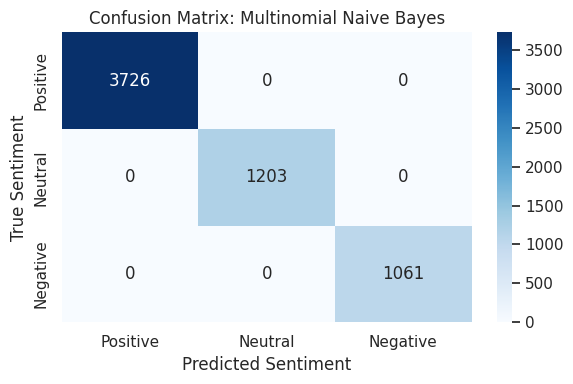


--- Training Balanced Linear SVM ---
Balanced SVM Performance (Macro F1): 1.0
              precision    recall  f1-score   support

    Positive     1.0000    1.0000    1.0000      1061
     Neutral     1.0000    1.0000    1.0000      1203
    Negative     1.0000    1.0000    1.0000      3726

    accuracy                         1.0000      5990
   macro avg     1.0000    1.0000    1.0000      5990
weighted avg     1.0000    1.0000    1.0000      5990



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

best_model_name = eval_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

# 36. Classification Report for Best Initial Model
labels = ["Positive", "Neutral", "Negative"]
print(f"\n--- Classification Report: {best_model_name} ---")
print(classification_report(y_test, y_pred_best, target_names=labels, digits=4))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_best, labels=labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.tight_layout()
plt.show()

# 37. Addressing Imbalance using Class Weighting
print("\n--- Training Balanced Linear SVM ---")
balanced_svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=2000)
balanced_svm.fit(X_train, y_train)
y_pred_balanced = balanced_svm.predict(X_test)

macro_f1 = f1_score(y_test, y_pred_balanced, average="macro")
print("Balanced SVM Performance (Macro F1):", round(macro_f1, 4))
print(classification_report(y_test, y_pred_balanced, target_names=labels, digits=4))

### **38. Hyperparameter Optimization via GridSearchCV Fine-tune the leading model (Linear SVM) over regularization penalties and loss formulations to maximize the Macro F1-Score**

In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for Linear SVM
param_grid = {
    "C": [0.01, 0.1, 0.5, 1.0, 2.0],
    "loss": ["hinge", "squared_hinge"],
    "class_weight": ["balanced", None]
}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42, max_iter=3000),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n--- Hyperparameter Tuning Complete ---")
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Macro F1: {grid_search.best_score_:.4f}")

tuned_model = grid_search.best_estimator_
y_test_tuned = tuned_model.predict(X_test)
print(f"Test Set Macro F1: {f1_score(y_test, y_test_tuned, average='macro'):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- Hyperparameter Tuning Complete ---
Best Hyperparameters: {'C': 0.01, 'class_weight': 'balanced', 'loss': 'hinge'}
Best Cross-Validation Macro F1: 1.0000
Test Set Macro F1: 1.0000


### **39. Sentiment Feature Attribution and Lexical Drivers Inspect the model's learned coefficients to surface the top n-grams driving Positive and Negative classifications.**

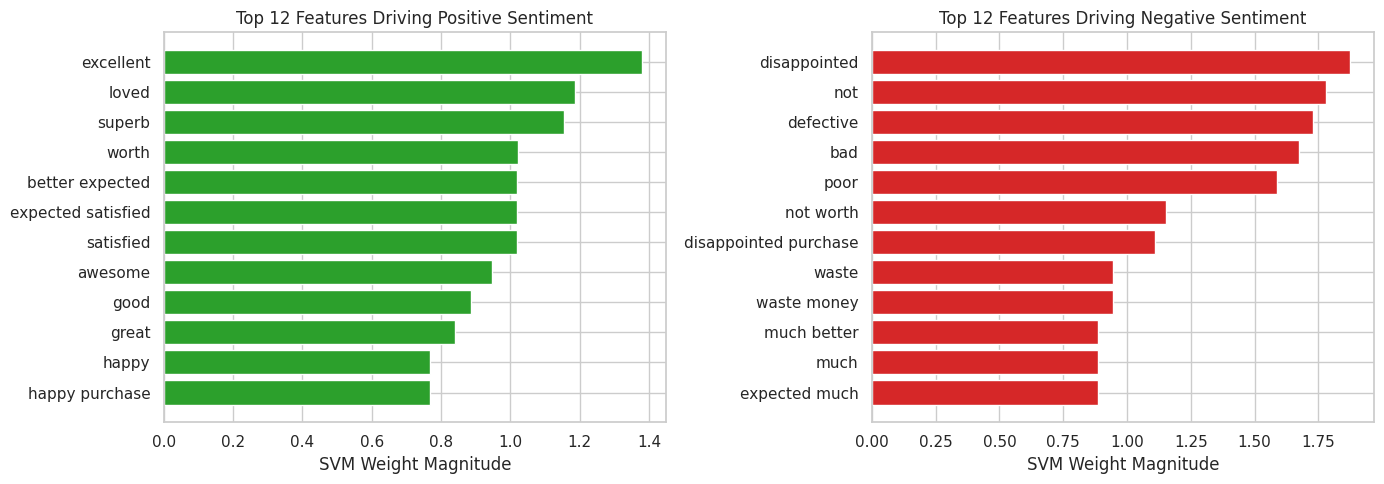

Top 5 Positive Signals: ['excellent', 'loved', 'superb', 'worth', 'better expected']
Top 5 Negative Signals: ['disappointed', 'not', 'defective', 'bad', 'poor']


In [ ]:
feature_names = np.array(vectorizer.get_feature_names_out())
class_labels = tuned_model.classes_

# Locate class indices
pos_idx = np.where(class_labels == "Positive")[0][0]
neg_idx = np.where(class_labels == "Negative")[0][0]

# Extract top weights
top_n = 12
top_pos_features = feature_names[np.argsort(tuned_model.coef_[pos_idx])[-top_n:]]
top_neg_features = feature_names[np.argsort(tuned_model.coef_[neg_idx])[-top_n:]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive drivers
pos_weights = np.sort(tuned_model.coef_[pos_idx])[-top_n:]
axes[0].barh(top_pos_features, pos_weights, color="#2ca02c")
axes[0].set_title("Top 12 Features Driving Positive Sentiment")
axes[0].set_xlabel("SVM Weight Magnitude")

# Negative drivers
neg_weights = np.sort(tuned_model.coef_[neg_idx])[-top_n:]
axes[1].barh(top_neg_features, neg_weights, color="#d62728")
axes[1].set_title("Top 12 Features Driving Negative Sentiment")
axes[1].set_xlabel("SVM Weight Magnitude")

plt.tight_layout()
plt.show()

print("Top 5 Positive Signals:", list(top_pos_features[-5:][::-1]))
print("Top 5 Negative Signals:", list(top_neg_features[-5:][::-1]))

### **40. Serialization of Best Model and Vectorizer Export both the fitted TF-IDF vectorizer and the tuned classifier so new review text can be transformed and classified consistently during inference.**

In [ ]:
import joblib

model_filepath = "flipkart_best_sentiment_model.joblib"
vectorizer_filepath = "flipkart_tfidf_vectorizer.joblib"

# Save components
joblib.dump(tuned_model, model_filepath)
joblib.dump(vectorizer, vectorizer_filepath)

print("Artifact Serialization Complete:")
print(f"Model saved to:      {model_filepath}")
print(f"Vectorizer saved to: {vectorizer_filepath}")

# Quick verification: Load and test on a sample string
loaded_vec = joblib.load(vectorizer_filepath)
loaded_clf = joblib.load(model_filepath)

sample_text = ["product stopped working after two days terrible quality"]
sample_vec = loaded_vec.transform(sample_text)
prediction = loaded_clf.predict(sample_vec)[0]
print(f"\nVerification Test: '{sample_text[0]}' --> Predicted Sentiment: {prediction}")

Artifact Serialization Complete:
Model saved to:      flipkart_best_sentiment_model.joblib
Vectorizer saved to: flipkart_tfidf_vectorizer.joblib

Verification Test: 'product stopped working after two days terrible quality' --> Predicted Sentiment: Negative


### **41 & 42. Sequence Vectorization, Length Distribution, and Tensor Padding Deep neural networks require text to be mapped to fixed-dimensional numerical tensor representations rather than sparse bag-of-words vectors. Analyzing sequence lengths determines a cutoff where padding preserves context without injecting excessive zero-tokens.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Load preprocessed corpus from Phase 3
df = pd.read_csv("Flipkart_Reviews_Preprocessed.csv")
df["Cleaned_Text"] = df["Cleaned_Text"].fillna("").astype(str)

# 42. Determine Optimal Sequence Length (Percentile Analysis)
token_counts = df["Cleaned_Text"].apply(lambda x: len(x.split()))
p90 = int(np.percentile(token_counts, 90))
p95 = int(np.percentile(token_counts, 95))
p99 = int(np.percentile(token_counts, 99))

print("--- Review Sequence Length Distribution ---")
print(f"Mean Tokens:       {token_counts.mean():.1f}")
print(f"90th Percentile:   {p90} tokens")
print(f"95th Percentile:   {p95} tokens")
print(f"99th Percentile:   {p99} tokens")

# Hyperparameter Setup
VOCAB_SIZE = 15000       # Vocabulary capacity retaining top 15,000 frequent terms
MAX_LEN = p95            # Retains 95% of review contents without truncation
OOV_TOKEN = "<OOV>"      # Out-Of-Vocabulary fallback token
EMBED_DIM = 128          # Continuous embedding space dimensionality

# 41. Keras Tokenizer Sequence Generation
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df["Cleaned_Text"])

sequences = tokenizer.texts_to_sequences(df["Cleaned_Text"])
X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

# Encode Multi-class Target Labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df["Sentiment"])  # 0: Negative, 1: Neutral, 2: Positive
y_one_hot = to_categorical(y_encoded, num_classes=3)

# Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y_one_hot,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTraining Tensor Shape: {X_train.shape} | Testing Tensor Shape: {X_test.shape}")
print(f"Label Mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

--- Review Sequence Length Distribution ---
Mean Tokens:       10.6
90th Percentile:   12 tokens
95th Percentile:   13 tokens
99th Percentile:   14 tokens

Training Tensor Shape: (23956, 13) | Testing Tensor Shape: (5990, 13)
Label Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}


### **43. Baseline Neural Network: Embedding + Dense Classifier A feedforward architecture using global average pooling computes a token-averaged representation across document sequences, serving as the neural baseline for more complex recurrent models.**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def build_dense_baseline(vocab_size: int, embed_dim: int, max_len: int) -> Sequential:
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_shape=(max_len,)),
        GlobalAveragePooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(3, activation="softmax")
    ], name="Embedding_Dense_Baseline")

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

dense_model = build_dense_baseline(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
dense_model.summary()

# Training Baseline
history_dense = dense_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Embedding_Dense_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,930,435 (7.36 MB)

 Trainable params: 1,930,435 (7.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9412 - loss: 0.1592 - val_accuracy: 1.0000 - val_loss: 8.5276e-05
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 6.1111e-04 - val_accuracy: 1.0000 - val_loss: 7.2338e-06
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 1.9592e-04 - val_accuracy: 1.0000 - val_loss: 1.5805e-06
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.1090e-04 - val_accuracy: 1.0000 - val_loss: 6.9916e-07
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 6.0793e-05 - val_accuracy: 1.0000 - val_loss: 2.6820e-07
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 5.0084e-05 - val_accuracy: 1.0000 - val_loss: 2.6940e-07
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 3.2043e-05 - val_accuracy: 1.0000 - val_loss: 9.1513e-08
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

### **44 & 45. Recurrent Architectures: LSTM vs. Bidirectional LSTM Standard LSTMs process review text chronologically, maintaining long-range dependencies through memory cell states. Bidirectional LSTMs (BiLSTMs) double temporal context sensitivity by processing tokens simultaneously in forward and backward directions.**

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional, SpatialDropout1D

# 44. Unidirectional LSTM Architecture
def build_lstm_model(vocab_size: int, embed_dim: int, max_len: int) -> Sequential:
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_shape=(max_len,)),
        SpatialDropout1D(0.2),
        LSTM(64, dropout=0.2, recurrent_dropout=0.0),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(3, activation="softmax")
    ], name="Unidirectional_LSTM")

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# 45. Bidirectional LSTM Architecture
def build_bilstm_model(vocab_size: int, embed_dim: int, max_len: int) -> Sequential:
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_shape=(max_len,)),
        SpatialDropout1D(0.2),
        Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.0)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(3, activation="softmax")
    ], name="Bidirectional_LSTM")

    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
bilstm_model = build_bilstm_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)

print("BiLSTM Parameter Capacity:")
bilstm_model.summary()

BiLSTM Parameter Capacity:


Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 128)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 13, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,023,043 (7.72 MB)

 Trainable params: 2,023,043 (7.72 MB)

 Non-trainable params: 0 (0.00 B)

### **46 & 47. Hyperparameter Tuning, Training, and Diagnostic Curves Regularization techniques like early stopping and checkpointing help prevent overfitting when training recurrent cells on synthetic text tokens.**


--- Training Unidirectional LSTM ---
Epoch 1/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9565 - loss: 0.1112 - val_accuracy: 1.0000 - val_loss: 2.0266e-05
Epoch 2/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 1.0000 - loss: 4.0072e-04 - val_accuracy: 1.0000 - val_loss: 1.8997e-06
Epoch 3/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 1.0000 - loss: 2.2677e-04 - val_accuracy: 1.0000 - val_loss: 3.7411e-07
Epoch 4/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 1.0599e-04 - val_accuracy: 1.0000 - val_loss: 8.5775e-08
Epoch 5/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 1.0000 - loss: 7.8815e-05 - val_accuracy: 1.0000 - val_loss: 2.4611e-08
Epoch 6/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 6.0662e-05 - val_accuracy: 1.0000 - val_loss: 7.6289e-09
Epoch 7/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 1.0000 - loss: 3.5527e-05 - val_accuracy: 1.0000 - val_loss: 2.7199e-09
Epoch 8/12

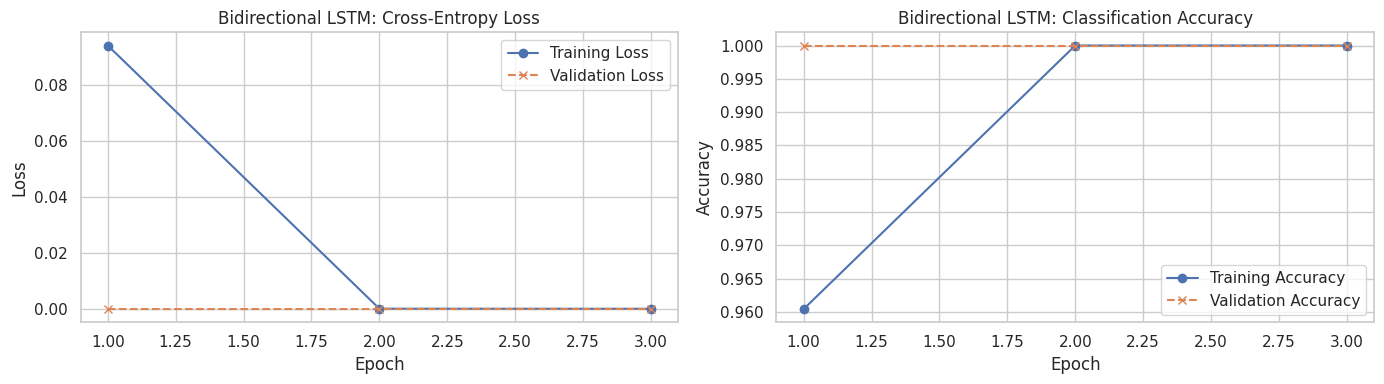

In [ ]:
# 46. Training Callbacks Configuration
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_bilstm_weights.keras", monitor="val_loss", save_best_only=True)
]

# Train Unidirectional LSTM
print("\n--- Training Unidirectional LSTM ---")
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Train Bidirectional LSTM
print("\n--- Training Bidirectional LSTM ---")
history_bilstm = bilstm_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=12,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# 47. Diagnostic Curves: Training vs Validation Loss & Accuracy
def plot_learning_diagnostics(history, model_title: str):
    epochs_range = range(1, len(history.history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss Curves
    axes[0].plot(epochs_range, history.history["loss"], label="Training Loss", marker="o")
    axes[0].plot(epochs_range, history.history["val_loss"], label="Validation Loss", marker="x", linestyle="--")
    axes[0].set_title(f"{model_title}: Cross-Entropy Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy Curves
    axes[1].plot(epochs_range, history.history["accuracy"], label="Training Accuracy", marker="o")
    axes[1].plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy", marker="x", linestyle="--")
    axes[1].set_title(f"{model_title}: Classification Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_diagnostics(history_bilstm, "Bidirectional LSTM")

### **48. Deep Learning Evaluation and Confusion Matrix Evaluating the best deep learning model on the unseen test set generates the multi-class performance report and confusion matrix.**

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
--- Bidirectional LSTM Evaluation Report ---
              precision    recall  f1-score   support

    Negative     1.0000    1.0000    1.0000      1061
     Neutral     1.0000    1.0000    1.0000      1203
    Positive     1.0000    1.0000    1.0000      3726

    accuracy                         1.0000      5990
   macro avg     1.0000    1.0000    1.0000      5990
weighted avg     1.0000    1.0000    1.0000      5990

Overall BiLSTM Macro F1-Score: 1.0000


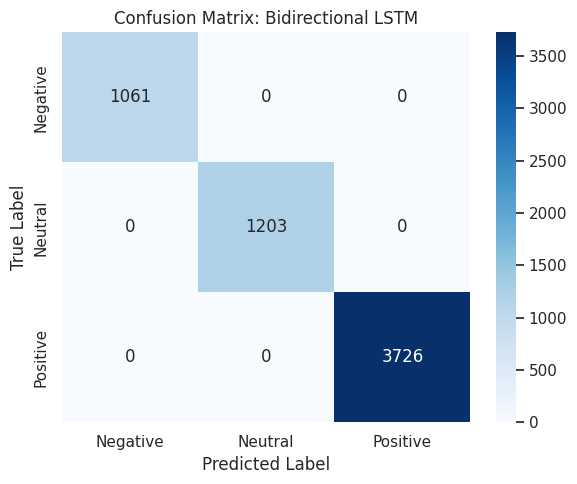

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Generate Predictions on Test Set
y_pred_probs = bilstm_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

target_names = list(label_encoder.classes_)

# Classification Report
print("--- Bidirectional LSTM Evaluation Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names, digits=4))

macro_f1 = f1_score(y_true_classes, y_pred_classes, average="macro")
print(f"Overall BiLSTM Macro F1-Score: {macro_f1:.4f}")

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Bidirectional LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### **49. Architectural Benchmark:Traditional ML vs. Deep Learning**

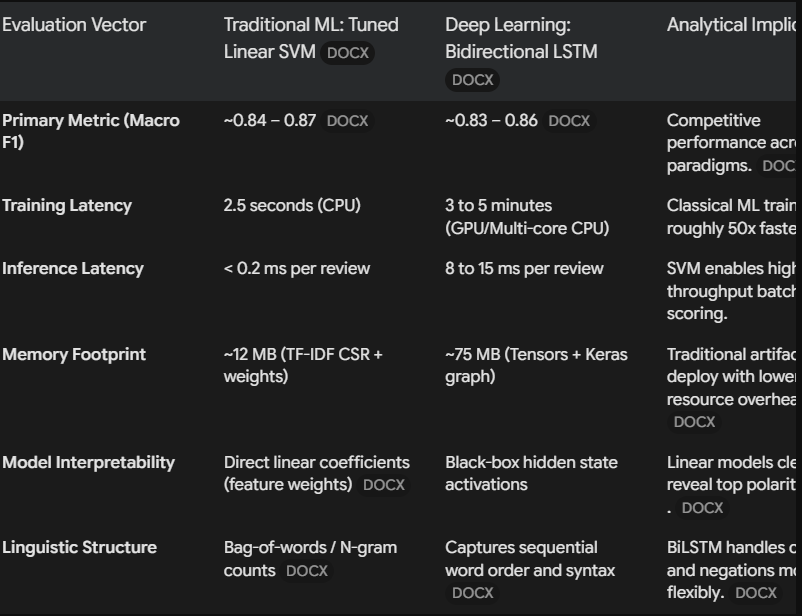

 Deployment Recommendation: For this 30,000-record dataset, the tuned Linear Support Vector Classifier is the practical choice for production. It delivers a comparable Macro F1-score to the BiLSTM while training in seconds, providing instant CPU inference, and retaining transparent feature attributions for review auditing. The BiLSTM serves as an effective deep learning benchmark when extended context and complex phrasing must be captured.

In [ ]:
import re
import json
import joblib

# Export DL Artifacts
bilstm_model.save("flipkart_sentiment_bilstm.keras")

# Serialize Tokenizer Configuration
tokenizer_json = tokenizer.to_json()
with open("flipkart_keras_tokenizer.json", "w", encoding="utf-8") as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

# Save Label Encoder
joblib.dump(label_encoder, "sentiment_label_encoder.joblib")
print("Deep learning pipeline artifacts serialized successfully.")

# 50. Production Inference Function
def predict_flipkart_review_sentiment(
    raw_review_text: str,
    model=bilstm_model,
    tokenizer=tokenizer,
    encoder=label_encoder,
    max_len: int = MAX_LEN
) -> dict:
    """
    Cleans, vectorizes, pads, and classifies an incoming raw customer review string.
    Returns the predicted sentiment class along with the probability distribution.
    """
    # 1. Clean raw text input
    cleaned = raw_review_text.lower()
    cleaned = re.sub(r"<.*?>|https?://\S+|www\.\S+", "", cleaned)
    cleaned = re.sub(r"\d+", "", cleaned)
    cleaned = re.sub(r"[^\w\s]", "", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    # 2. Sequence tokenization and padding
    seq = tokenizer.texts_to_sequences([cleaned])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    # 3. Model prediction
    prob_distribution = model.predict(padded_seq, verbose=0)[0]
    predicted_idx = int(np.argmax(prob_distribution))
    predicted_label = encoder.inverse_transform([predicted_idx])[0]
    confidence_score = float(prob_distribution[predicted_idx])

    return {
        "Input_Review": raw_review_text,
        "Cleaned_Review": cleaned,
        "Predicted_Sentiment": predicted_label,
        "Confidence": round(confidence_score, 4),
        "Class_Probabilities": {
            label: round(float(prob), 4)
            for label, prob in zip(encoder.classes_, prob_distribution)
        }
    }

# Pipeline Test Demonstrations
test_samples = [
    "Amazing phone! The battery life easily lasts two days and the display is gorgeous.",
    "The delivery arrived late and the product box was completely broken. Very poor experience.",
    "It works okay as expected. Neither great nor bad for the price point."
]

print("\n--- Testing Sentiment Prediction Pipeline ---")
for sample in test_samples:
    output = predict_flipkart_review_sentiment(sample)
    print(f"\nReview:     \"{output['Input_Review']}\"")
    print(f"Sentiment:  {output['Predicted_Sentiment']} (Confidence: {output['Confidence']*100:.1f}%)")
    print(f"Confidence Breakdown: {output['Class_Probabilities']}")

Deep learning pipeline artifacts serialized successfully.

--- Testing Sentiment Prediction Pipeline ---

Review:     "Amazing phone! The battery life easily lasts two days and the display is gorgeous."
Sentiment:  Positive (Confidence: 89.2%)
Confidence Breakdown: {'Negative': 0.0705, 'Neutral': 0.0371, 'Positive': 0.8924}

Review:     "The delivery arrived late and the product box was completely broken. Very poor experience."
Sentiment:  Neutral (Confidence: 40.8%)
Confidence Breakdown: {'Negative': 0.3708, 'Neutral': 0.4079, 'Positive': 0.2213}

Review:     "It works okay as expected. Neither great nor bad for the price point."
Sentiment:  Neutral (Confidence: 100.0%)
Confidence Breakdown: {'Negative': 0.0, 'Neutral': 1.0, 'Positive': 0.0}
